In [1]:
from IPython.display import display, HTML 
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:15pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:15pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

In [19]:
# import
import numpy as np
import seaborn as sns # iris데이터
import pandas as pd # 원핫인코딩
from sklearn.preprocessing import LabelEncoder # 라벨인코디 (문자 -> 숫자)
from tensorflow.keras.utils import to_categorical # 원핫인코딩
from sklearn.model_selection import train_test_split # 데이터 분할(층화추출로)
from tensorflow.keras.models import Sequential, load_model, save_model
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pylab as plt # 학습과정 시각화

- iris데이터
1. sepal_length : 꽃받침길이
2. sepal_width: 꽃받침넓이
3. petal_length: 꽃잎길이
4. petal_width: 꽃잎길이
5. species : 꽃 종

In [8]:
# 문자변수의 원핫인코딩 방법 1
iris = sns.load_dataset('iris')
iris.head()
# to_categorical(iris['species'])
labelEncoder = LabelEncoder()
# labelEncoder.fit(iris['species'])
# iris['y'] = labelEncoder.transform(iris['species'])
iris['y'] = labelEncoder.fit_transform(iris.species)
# iris.iloc[::25]
to_categorical(iris['y'])[::25] # to_categorical의 결과는 numpy배열

array([[1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.]], dtype=float32)

In [10]:
# 문자변수 원핫인코딩 방법2
iris = sns.load_dataset('iris')
pd.get_dummies(iris.species).values # pd.get_dummies결과는 데이터 프레임
pd.get_dummies(iris.species).to_numpy()[::25]

array([[1, 0, 0],
       [1, 0, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 0, 1],
       [0, 0, 1]], dtype=uint8)

In [38]:
# 1. 데이터 생성 및 전처리
iris = sns.load_dataset('iris')
# iris.info() 결측치 있으면 처리 필요
iris['species'].value_counts() # 타겟변수의 분포
# 독립변수와 타겟변수 분리
iris_X = iris.iloc[:,:-1].to_numpy()
# iris_X[:2]
iris_y = iris.iloc[:,-1]
iris_Y =pd.get_dummies(iris_y).values
print(iris_Y[::50])
# 훈련셋 : 테스트셋 = 8.2
X_train, X_test, Y_train, Y_test = train_test_split(iris_X, iris_Y,
                                                   test_size=0.2,
                                                   stratify=iris_Y, # 층화추출
                                                   random_state=7 # 랜덤시스값
                                                   )
print(iris_X.shape, iris_Y.shape)
print(X_train.shape, X_test.shape, Y_train.shape, Y_test.shape)

[[1 0 0]
 [0 1 0]
 [0 0 1]]
(150, 4) (150, 3)
(120, 4) (30, 4) (120, 3) (30, 3)


In [39]:
# 층화추출이 되었는지 확인
# iris_Y.argmax(axir=1)
print(pd.Series(np.argmax(iris_Y,axis=1)).value_counts())
print(pd.Series(np.argmax(Y_train,axis=1)).value_counts())
print(pd.Series(np.argmax(Y_test,axis=1)).value_counts())

0    50
1    50
2    50
dtype: int64
0    40
2    40
1    40
dtype: int64
0    10
2    10
1    10
dtype: int64


In [40]:
# 2. 모델구성(입력4, 출력3)
model = Sequential()
model.add(Dense(units=64, input_dim=4, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(units=128, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(units=50, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(units=30, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(units=3, activation='softmax')) # 출력층
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_15 (Dense)            (None, 64)                320       
                                                                 
 dropout_8 (Dropout)         (None, 64)                0         
                                                                 
 dense_16 (Dense)            (None, 128)               8320      
                                                                 
 dropout_9 (Dropout)         (None, 128)               0         
                                                                 
 dense_17 (Dense)            (None, 50)                6450      
                                                                 
 dropout_10 (Dropout)        (None, 50)                0         
                                                                 
 dense_18 (Dense)            (None, 30)               

In [41]:
# 3. 학습과정 설정
model.compile(loss='categorical_crossentropy',
             optimizer='adam',
             metrics=['accuracy'])
# 4. 학습: epoch마다 val_accuracy값이 좋아지고 있으면 model 자동 저장(콜백 추가)
# 모델 자동 저장 경로(ex) : ./model_iris/iris_002-val0.6743.h5
import os
model_save_folder = './model_iris/'
if not os.path.exists(model_save_folder): # 폴더가 없으면 폴더 생성
    os.mkdir(model_save_folder)
file = model_save_folder + 'iris-{epoch:03d}-val{val_accuracy:.4f}.h5'
# 모델 자동 저장할 콜백 객체
checkpoint = ModelCheckpoint(filepath=file,
                             monitor='val_accuracy', # 모니터링 지표 (기본값: val_loss)
                             mode='max',
                             save_best_only=True, # False : 매번 저장
                             verbose=1) # 모델 저장시 로그 출력 (0: 로그출력 안함)
# 조기 종료 콜백 객체
earlyStopping = EarlyStopping(patience=40) # monitor 기본값은 val_loss
hist = model.fit(X_train, Y_train,
                # batchsize=40,
                epochs=500,
                validation_split=0.3, # 훈력셋의 30%를 검증셋
                callbacks=[earlyStopping, checkpoint])

Epoch 1/500
1/3 [=========>....................] - ETA: 1s - loss: 1.2456 - accuracy: 0.3438
Epoch 1: val_accuracy improved from -inf to 0.36111, saving model to ./model_iris\iris-001-val0.3611.h5
3/3 [==============================] - 1s 117ms/step - loss: 1.2771 - accuracy: 0.2976 - val_loss: 1.0210 - val_accuracy: 0.3611
Epoch 2/500
1/3 [=========>....................] - ETA: 0s - loss: 1.2186 - accuracy: 0.2812
Epoch 2: val_accuracy improved from 0.36111 to 0.66667, saving model to ./model_iris\iris-002-val0.6667.h5
3/3 [==============================] - 0s 39ms/step - loss: 1.1171 - accuracy: 0.3810 - val_loss: 1.0119 - val_accuracy: 0.6667
Epoch 3/500
1/3 [=========>....................] - ETA: 0s - loss: 1.0211 - accuracy: 0.4375
Epoch 3: val_accuracy did not improve from 0.66667
3/3 [==============================] - 0s 19ms/step - loss: 1.1308 - accuracy: 0.3690 - val_loss: 1.0144 - val_accuracy: 0.6389
Epoch 4/500
1/3 [=========>....................] - ETA: 0s - loss: 1.0767 

1/3 [=========>....................] - ETA: 0s - loss: 0.4953 - accuracy: 0.6562
Epoch 30: val_accuracy did not improve from 0.75000
3/3 [==============================] - 0s 18ms/step - loss: 0.4929 - accuracy: 0.6786 - val_loss: 0.4107 - val_accuracy: 0.7500
Epoch 31/500
1/3 [=========>....................] - ETA: 0s - loss: 0.5173 - accuracy: 0.7500
Epoch 31: val_accuracy did not improve from 0.75000
3/3 [==============================] - 0s 19ms/step - loss: 0.4704 - accuracy: 0.7857 - val_loss: 0.4114 - val_accuracy: 0.7500
Epoch 32/500
1/3 [=========>....................] - ETA: 0s - loss: 0.4750 - accuracy: 0.6875
Epoch 32: val_accuracy did not improve from 0.75000
3/3 [==============================] - 0s 17ms/step - loss: 0.4480 - accuracy: 0.7619 - val_loss: 0.4289 - val_accuracy: 0.7500
Epoch 33/500
1/3 [=========>....................] - ETA: 0s - loss: 0.4583 - accuracy: 0.8125
Epoch 33: val_accuracy did not improve from 0.75000
3/3 [==============================] - 0s 18m

Epoch 59/500
1/3 [=========>....................] - ETA: 0s - loss: 0.2718 - accuracy: 0.8750
Epoch 59: val_accuracy did not improve from 0.97222
3/3 [==============================] - 0s 17ms/step - loss: 0.2840 - accuracy: 0.8810 - val_loss: 0.2262 - val_accuracy: 0.9722
Epoch 60/500
1/3 [=========>....................] - ETA: 0s - loss: 0.2277 - accuracy: 0.8750
Epoch 60: val_accuracy did not improve from 0.97222
3/3 [==============================] - 0s 24ms/step - loss: 0.2858 - accuracy: 0.8810 - val_loss: 0.2207 - val_accuracy: 0.9722
Epoch 61/500
1/3 [=========>....................] - ETA: 0s - loss: 0.2126 - accuracy: 0.9688
Epoch 61: val_accuracy did not improve from 0.97222
3/3 [==============================] - 0s 19ms/step - loss: 0.2615 - accuracy: 0.9048 - val_loss: 0.2191 - val_accuracy: 0.9722
Epoch 62/500
1/3 [=========>....................] - ETA: 0s - loss: 0.2887 - accuracy: 0.8125
Epoch 62: val_accuracy did not improve from 0.97222
3/3 [===========================

Epoch 89/500
1/3 [=========>....................] - ETA: 0s - loss: 0.1339 - accuracy: 0.9688
Epoch 89: val_accuracy did not improve from 0.97222
3/3 [==============================] - 0s 18ms/step - loss: 0.1388 - accuracy: 0.9405 - val_loss: 0.1977 - val_accuracy: 0.9444
Epoch 90/500
1/3 [=========>....................] - ETA: 0s - loss: 0.1616 - accuracy: 0.9375
Epoch 90: val_accuracy did not improve from 0.97222
3/3 [==============================] - 0s 19ms/step - loss: 0.1557 - accuracy: 0.9405 - val_loss: 0.2252 - val_accuracy: 0.9167
Epoch 91/500
1/3 [=========>....................] - ETA: 0s - loss: 0.2150 - accuracy: 0.9375
Epoch 91: val_accuracy did not improve from 0.97222
3/3 [==============================] - 0s 18ms/step - loss: 0.1729 - accuracy: 0.9405 - val_loss: 0.1745 - val_accuracy: 0.9444
Epoch 92/500
1/3 [=========>....................] - ETA: 0s - loss: 0.0399 - accuracy: 1.0000
Epoch 92: val_accuracy did not improve from 0.97222
3/3 [===========================

Epoch 119/500
1/3 [=========>....................] - ETA: 0s - loss: 0.1382 - accuracy: 0.9688
Epoch 119: val_accuracy did not improve from 0.97222
3/3 [==============================] - 0s 20ms/step - loss: 0.1363 - accuracy: 0.9643 - val_loss: 0.1820 - val_accuracy: 0.9444
Epoch 120/500
1/3 [=========>....................] - ETA: 0s - loss: 0.1498 - accuracy: 0.9375
Epoch 120: val_accuracy did not improve from 0.97222
3/3 [==============================] - 0s 19ms/step - loss: 0.1301 - accuracy: 0.9643 - val_loss: 0.2069 - val_accuracy: 0.9444
Epoch 121/500
1/3 [=========>....................] - ETA: 0s - loss: 0.0629 - accuracy: 1.0000
Epoch 121: val_accuracy did not improve from 0.97222
3/3 [==============================] - 0s 18ms/step - loss: 0.0832 - accuracy: 0.9762 - val_loss: 0.1977 - val_accuracy: 0.9444
Epoch 122/500
1/3 [=========>....................] - ETA: 0s - loss: 0.2491 - accuracy: 0.9062
Epoch 122: val_accuracy did not improve from 0.97222
3/3 [===================

Epoch 149/500
1/3 [=========>....................] - ETA: 0s - loss: 0.0637 - accuracy: 1.0000
Epoch 149: val_accuracy did not improve from 0.97222
3/3 [==============================] - 0s 18ms/step - loss: 0.1253 - accuracy: 0.9762 - val_loss: 0.2784 - val_accuracy: 0.9167
Epoch 150/500
1/3 [=========>....................] - ETA: 0s - loss: 0.1740 - accuracy: 0.9688
Epoch 150: val_accuracy did not improve from 0.97222
3/3 [==============================] - 0s 18ms/step - loss: 0.1260 - accuracy: 0.9643 - val_loss: 0.2189 - val_accuracy: 0.9167
Epoch 151/500
1/3 [=========>....................] - ETA: 0s - loss: 0.0684 - accuracy: 1.0000
Epoch 151: val_accuracy did not improve from 0.97222
3/3 [==============================] - 0s 19ms/step - loss: 0.0679 - accuracy: 0.9762 - val_loss: 0.1762 - val_accuracy: 0.9444
Epoch 152/500
1/3 [=========>....................] - ETA: 0s - loss: 0.1057 - accuracy: 0.9688
Epoch 152: val_accuracy did not improve from 0.97222
3/3 [===================

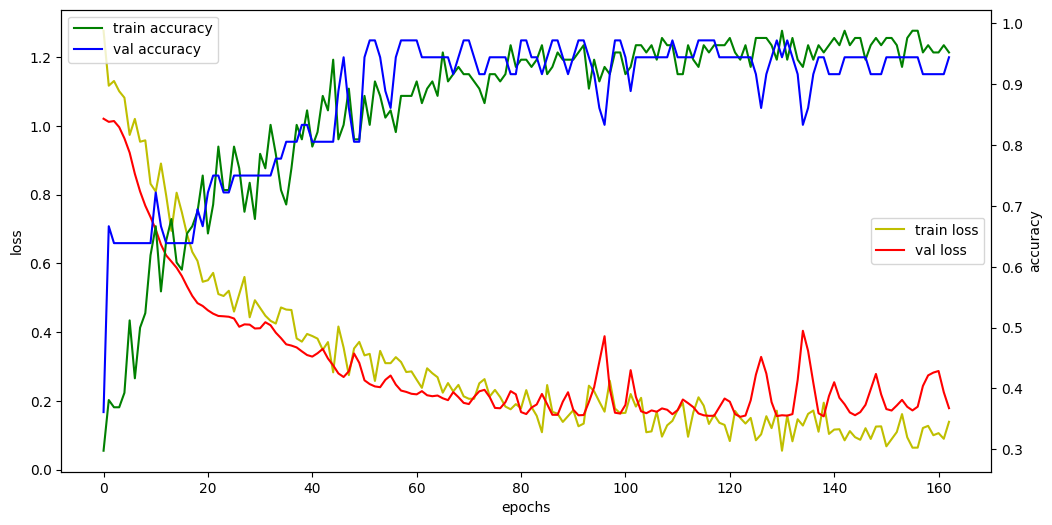

In [42]:
fig, loss_ax = plt.subplots(figsize=(12,6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right')
acc_ax.legend()
plt.show()

In [54]:
# 6. 모델평가(evaluate: 테스트셋, 교차표, recall, precision : y실제값, y예측값)
# iris-052-val0.9722.h5 모델도 같이 평가
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score, precision_score, f1_score
# 학습된 모델
loss, acc = model.evaluate(X_test, Y_test)
loss, acc
# 모델의 recall과 precision을 위해서 실제값과 예측값
real = np.argmax(Y_test, axis=1)
pred = np.argmax(model.predict(X_test), axis=1)
recl = recall_score(real, pred, average='weighted') # average='weighted': 다중분류시 사용
prec = precision_score(real, pred, average='weighted')
f1   = f1_score(real, pred, average='weighted')
print('model accuracy: ', acc)
print('model recall: ', recl)
print('model precision: ', prec)
print('model f1 score:', f1)
# 저장된 모델의 평가
model2 = load_model('model_iris/iris-052-val0.9722.h5')
loss2, acc2 = model2.evaluate(X_test, Y_test)
pred2 = np.argmax(model2.predict(X_test), axis=1)
recl2 = recall_score(real, pred2, average='weighted') # average='weighted': 다중분류시 사용
prec2 = precision_score(real, pred2, average='weighted')
f1_2   = f1_score(real, pred2, average='weighted')
print('model accuracy: ', acc2)
print('model recall: ', recl2)
print('model precision: ', prec2)
print('model f1 score:', f1_2)

1/1 [==============================] - 0s 15ms/step
model accuracy:  1.0
model recall:  1.0
model precision:  1.0
model f1 score: 1.0
1/1 [==============================] - 0s 71ms/step
model accuracy:  1.0
model recall:  1.0
model precision:  1.0
model f1 score: 1.0


In [53]:
# 교차표
pred = np.argmax(model2.predict(X_test, verbose=0), axis=1)
pd.crosstab(real, pred,
           rownames=['real'], colnames=['pred'])

pred,0,1,2
real,,,
0,10,0,0
1,0,10,0
2,0,1,9


In [56]:
# 모델 저장 및 사용
save_model(model, 'model_iris/iris.h5')
model.save('model_iris/iris.h5') # tensorflow2.18 이상일 경우 확장자를 .keras로도 사용할 수 있음

In [59]:
# 모델 예측하기 
# iris.loc[100] (6.3, 3.3, 6.0, 2.5) 예측하기
result = model.predict([[6.3, 3.3, 6.0, 2.5]])
np.argmax(result)

1/1 [==============================] - 0s 52ms/step


2